In [ ]:
import pandas as pd
import numpy as np

from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score
)

import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import seaborn as sns
import plotly.express as px

In [ ]:
# Cargar datos
# saber Pro
df_pro = pd.read_csv("Dataset_Final_LimpioSaberPro.csv", encoding='utf-8')

In [ ]:
# Saber 11 (archivo aparte)
df_saber11 = pd.read_csv("datos_filtradoSaber11.csv", encoding='utf-8')

In [ ]:
df_keys = pd.read_csv("ids_sb11_sbpro_filtrados.csv")

In [ ]:
df_pro.columns = df_pro.columns.str.lower()
df_saber11.columns = df_saber11.columns.str.lower()
df_keys.columns = df_keys.columns.str.lower()

In [ ]:
# Unir datasets
df_pro_keyed = pd.merge(
    df_pro,
    df_keys,
    left_on="estu_consecutivo",
    right_on="estu_consecutivo_sbpro",
    how="inner"
)

df_full = pd.merge(
    df_pro_keyed,
    df_saber11,
    left_on="estu_consecutivo_sb11",
    right_on="estu_consecutivo",
    how="inner",
    suffixes=("_pro", "_sb11")
)

# Variables de cada examen
vars_11 = [
    "punt_lectura_critica",
    "punt_matematicas",
    "punt_sociales_ciudadanas",
    "punt_c_naturales",
    "punt_ingles"
]

vars_pro = [
    "mod_lectura_critica_punt",
    "mod_razona_cuantitat_punt",
    "mod_competen_ciudada_punt",
    "mod_ingles_punt"
]

In [ ]:
# Eliminar NA solo en variables necesarias
df_clean = df_full[vars_11 + vars_pro].dropna().copy()


In [ ]:
# Limpiar datos necesarios
df_clean = df_full[vars_pro + ["punt_global"]].dropna().copy()

In [ ]:
# Puntaje promedio por estudiante (Saber Pro)
df_clean["promedio_saber_pro"] = df_clean[vars_pro].mean(axis=1)

In [ ]:
# PROMEDIOS GENERALES
promedio_saber11 = df_clean["punt_global"].mean()
promedio_saber_pro = df_clean["promedio_saber_pro"].mean()

In [ ]:
print("Promedio general Saber 11:", round(promedio_saber11, 2))
print("Promedio general Saber Pro:", round(promedio_saber_pro, 2))

Promedio general Saber 11: 344.84
Promedio general Saber Pro: 182.39


In [ ]:
# ===============================
# FILTRAR ÁREAS DE INTERÉS (CLAVE)
# ===============================
gestion = [
    "GESTIÓN DE ORGANIZACIONES",
    "GESTIÓN FINANCIERA",
    "ANÁLISIS ECONÓMICO",
    "INFORMACIÓN Y CONTROL CONTABLE",
    "FORMULACIÓN, EVALUACIÓN Y GESTIÓN DE PROYECTOS"
]

df_pro_filtrado = df_pro[
    df_pro["result_nombreprueba"].isin(gestion)
].copy()


In [ ]:
# Limpiar
df_clean = df_full[["estu_consecutivo_sbpro", "punt_global"] + vars_pro].dropna().copy()

# 🔥 AGRUPAR POR ESTUDIANTE (CLAVE)
df_student = df_clean.groupby("estu_consecutivo_sbpro").agg({
    "punt_global": "first",  # es el mismo para cada fila del estudiante
    **{var: "mean" for var in vars_pro}  # promedio de módulos
}).reset_index()

# Promedio Saber Pro por estudiante
df_student["promedio_saber_pro"] = df_student[vars_pro].mean(axis=1)

# Promedios finales
promedio_saber11 = df_student["punt_global"].mean()
promedio_saber_pro = df_student["promedio_saber_pro"].mean()

print("Promedio Saber 11:", round(promedio_saber11, 2))
print("Promedio Saber Pro:", round(promedio_saber_pro, 2))

Promedio Saber 11: 344.96
Promedio Saber Pro: 182.47


In [ ]:
df_clean.head()

,estu_consecutivo_sbpro,punt_global,mod_lectura_critica_punt,mod_razona_cuantitat_punt,mod_competen_ciudada_punt,mod_ingles_punt
9,EK201950108608,360.0,192,203,194,205
10,EK201950194008,335.0,195,197,194,209
12,EK201950110424,345.0,170,177,173,208
13,EK201950115480,349.0,174,170,177,216
16,EK201950102897,327.0,207,163,171,186


In [ ]:
df_student["area_gestion"] = df_student["estu_consecutivo_sbpro"].isin(
    df_pro_filtrado["estu_consecutivo"]
)

df_student.groupby("area_gestion")["punt_global"].describe()

,count,mean,std,min,25%,50%,75%,max
area_gestion,,,,,,,,
False,16881.0,345.609620,38.164286,161.0,322.0,347.0,369.0,492.0
True,1679.0,338.477665,34.518041,222.0,317.0,338.0,361.5,476.0


In [ ]:
df_student["punt_global"].mean()

np.float64(344.96443965517244)

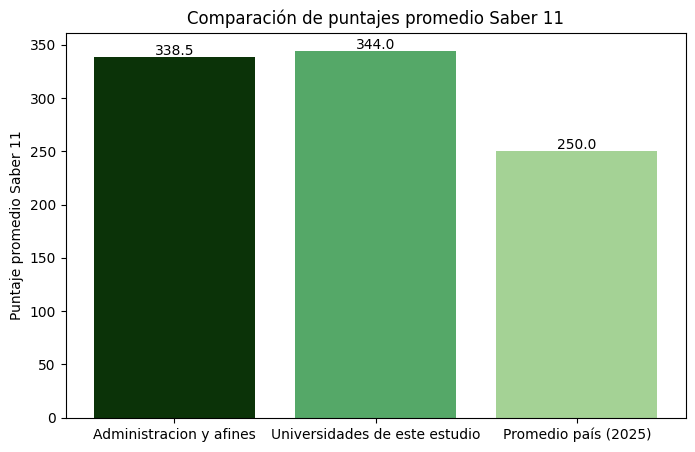

In [ ]:
import matplotlib.pyplot as plt

labels = [
    "Administracion y afines",
    "Universidades de este estudio",
    "Promedio país (2025)"
]

valores = [338.48, 344.0, 250.0]

colores = ["#0b3308", "#55A868", "#a4d295"]

plt.figure(figsize=(8,5))
plt.bar(labels, valores, color=colores)

plt.ylabel("Puntaje promedio Saber 11")
plt.title("Comparación de puntajes promedio Saber 11")

# Valores encima de las barras
for i, v in enumerate(valores):
    plt.text(i, v + 2, str(round(v, 1)), ha='center')

plt.show()

In [ ]:

# ===============================
# VARIABLES
# ===============================
vars_11 = [
    "punt_lectura_critica",
    "punt_matematicas",
    "punt_sociales_ciudadanas",
    "punt_c_naturales",
    "punt_ingles"
]

gestion = [
    "GESTIÓN DE ORGANIZACIONES",
    "GESTIÓN FINANCIERA",
    "ANÁLISIS ECONÓMICO",
    "INFORMACIÓN Y CONTROL CONTABLE",
    "FORMULACIÓN, EVALUACIÓN Y GESTIÓN DE PROYECTOS"
]


In [ ]:
# ===============================
# 1. PROMEDIO TOTAL UNIVERSIDADES
# ===============================
df_total = df_full[vars_11].dropna().copy()
prom_total = df_total.mean()

# ===============================
# 2. IDENTIFICAR ESTUDIANTES DE GESTIÓN
# ===============================
ids_gestion = df_pro[
    df_pro["result_nombreprueba"].isin(gestion)
]["estu_consecutivo"].unique()

df_gestion = df_full[
    df_full["estu_consecutivo_sbpro"].isin(ids_gestion)
][vars_11].dropna().copy()

prom_gestion = df_gestion.mean()


In [ ]:
# ===============================
# 3. ORGANIZAR RESULTADOS
# ===============================
df_plot = pd.DataFrame({
    "Total universidades": prom_total,
    "Gestión": prom_gestion
})

df_plot = df_plot.reset_index().rename(columns={"index": "Modulo"})

In [ ]:
prom_pais = {
    "punt_lectura_critica": 53.0,
    "punt_matematicas": 51.0,
    "punt_sociales_ciudadanas": 48.0,
    "punt_c_naturales": 49.0,
    "punt_ingles": 49.0
}

# Mapear correctamente
df_plot["País (2024)"] = df_plot["Modulo"].map(prom_pais)

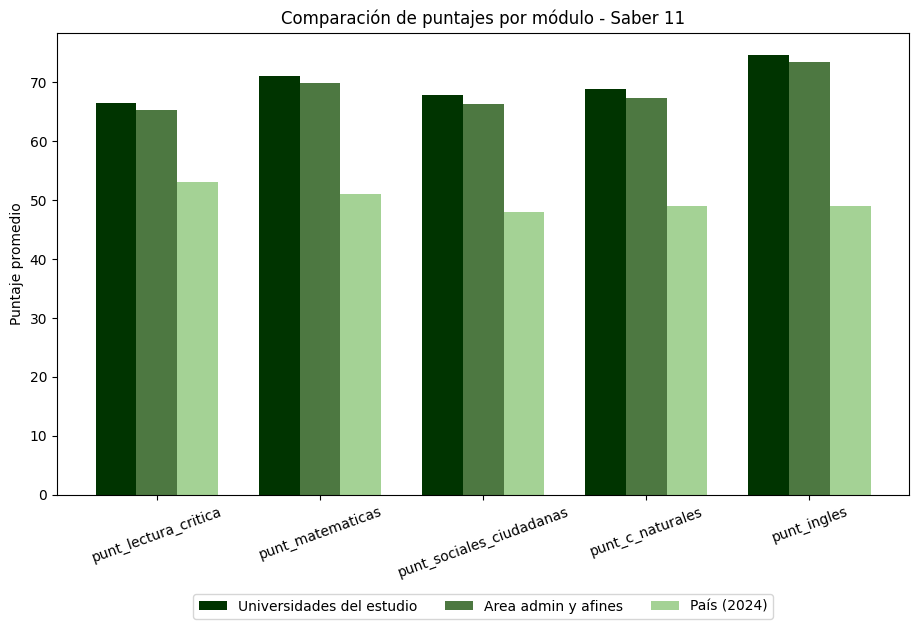

In [ ]:
x = range(len(df_plot))

plt.figure(figsize=(11,6))

# Total universidades
plt.bar(
    [i - 0.25 for i in x],
    df_plot["Total universidades"],
    width=0.25,
    label="Universidades del estudio",
    color="#003400"
)

# Gestión
plt.bar(
    [i for i in x],
    df_plot["Gestión"],
    width=0.25,
    label="Area admin y afines",
    color="#4d7841"
)

# País
plt.bar(
    [i + 0.25 for i in x],
    df_plot["País (2024)"],
    width=0.25,
    label="País (2024)",
    color="#a4d295"
)

# Estética
plt.xticks(x, df_plot["Modulo"], rotation=20)
plt.ylabel("Puntaje promedio")
plt.title("Comparación de puntajes por módulo - Saber 11")

plt.legend(    loc='upper center',
    bbox_to_anchor=(0.5, -0.20),
    ncol=3)
plt.show()

In [ ]:
# ===============================
# VARIABLES SABER PRO
# ===============================
vars_pro = [
    "mod_lectura_critica_punt",
    "mod_razona_cuantitat_punt",
    "mod_competen_ciudada_punt",
    "mod_ingles_punt"
]

gestion = [
    "GESTIÓN DE ORGANIZACIONES",
    "GESTIÓN FINANCIERA",
    "ANÁLISIS ECONÓMICO",
    "INFORMACIÓN Y CONTROL CONTABLE",
    "FORMULACIÓN, EVALUACIÓN Y GESTIÓN DE PROYECTOS"
]

In [ ]:
# ===============================
# 1. PROMEDIO TOTAL UNIVERSIDADES
# ===============================
df_total = df_full[vars_pro].dropna().copy()
df_total["promedio_pro"] = df_total.mean(axis=1)

prom_total = df_total["promedio_pro"].mean()

# ===============================
# 2. PROMEDIO GESTIÓN
# ===============================
ids_gestion = df_pro[
    df_pro["result_nombreprueba"].isin(gestion)
]["estu_consecutivo"].unique()

df_gestion = df_full[
    df_full["estu_consecutivo_sbpro"].isin(ids_gestion)
][vars_pro].dropna().copy()

df_gestion["promedio_pro"] = df_gestion.mean(axis=1)

prom_gestion = df_gestion["promedio_pro"].mean()


In [ ]:
# ===============================
# 3. PROMEDIO PAÍS
# ===============================
prom_pais = 146

print("Total universidades:", round(prom_total, 2))
print("Gestión:", round(prom_gestion, 2))
print("País (2024):", prom_pais)

Total universidades: 180.78
Gestión: 176.84
País (2024): 146


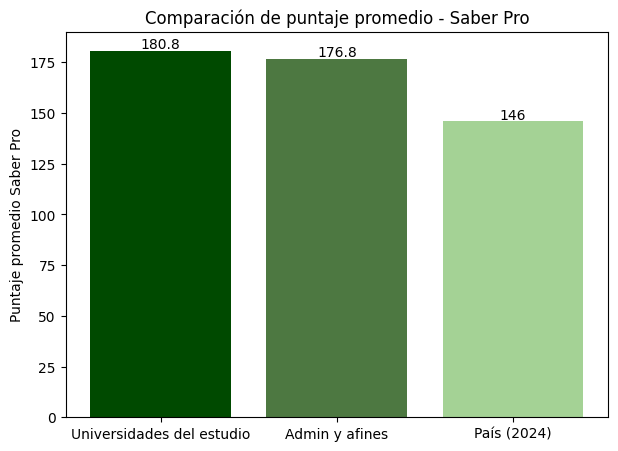

In [ ]:
labels = ["Universidades del estudio", "Admin y afines", "País (2024)"]
valores = [prom_total, prom_gestion, prom_pais]

colores = ["#004a00", "#4d7841", "#a4d295"]

plt.figure(figsize=(7,5))
plt.bar(labels, valores, color=colores)

plt.ylabel("Puntaje promedio Saber Pro")
plt.title("Comparación de puntaje promedio - Saber Pro")

for i, v in enumerate(valores):
    plt.text(i, v + 1, str(round(v, 1)), ha='center')

plt.show()

In [ ]:
# ===============================
# VARIABLES
# ===============================
vars_pro = [
    "mod_lectura_critica_punt",
    "mod_comuni_escrita_punt",
    "mod_razona_cuantitat_punt",
    "mod_competen_ciudada_punt",
    "mod_ingles_punt"
]

gestion = [
    "GESTIÓN DE ORGANIZACIONES",
    "GESTIÓN FINANCIERA",
    "ANÁLISIS ECONÓMICO",
    "INFORMACIÓN Y CONTROL CONTABLE",
    "FORMULACIÓN, EVALUACIÓN Y GESTIÓN DE PROYECTOS"
]


In [ ]:
# ===============================
# 1. TOTAL UNIVERSIDADES
# ===============================
df_total = df_full[vars_pro].dropna().copy()
prom_total = df_total.mean()

# ===============================
# 2. GESTIÓN
# ===============================
ids_gestion = df_pro[
    df_pro["result_nombreprueba"].isin(gestion)
]["estu_consecutivo"].unique()

df_gestion = df_full[
    df_full["estu_consecutivo_sbpro"].isin(ids_gestion)
][vars_pro].dropna().copy()

prom_gestion = df_gestion.mean()


In [ ]:
# ===============================
# 3. PROMEDIO PAÍS
# ===============================
prom_pais = {
    "mod_lectura_critica_punt": 147,
    "mod_comuni_escrita_punt": 145,
    "mod_razona_cuantitat_punt": 142,
    "mod_competen_ciudada_punt": 140,
    "mod_ingles_punt": 148
}

In [ ]:
# ===============================
# 4. ORGANIZAR
# ===============================
df_plot = pd.DataFrame({
    "Total universidades": prom_total,
    "Gestión": prom_gestion
})

df_plot = df_plot.reset_index().rename(columns={"index": "Modulo"})

# Agregar país
df_plot["País (2024)"] = df_plot["Modulo"].map(prom_pais)

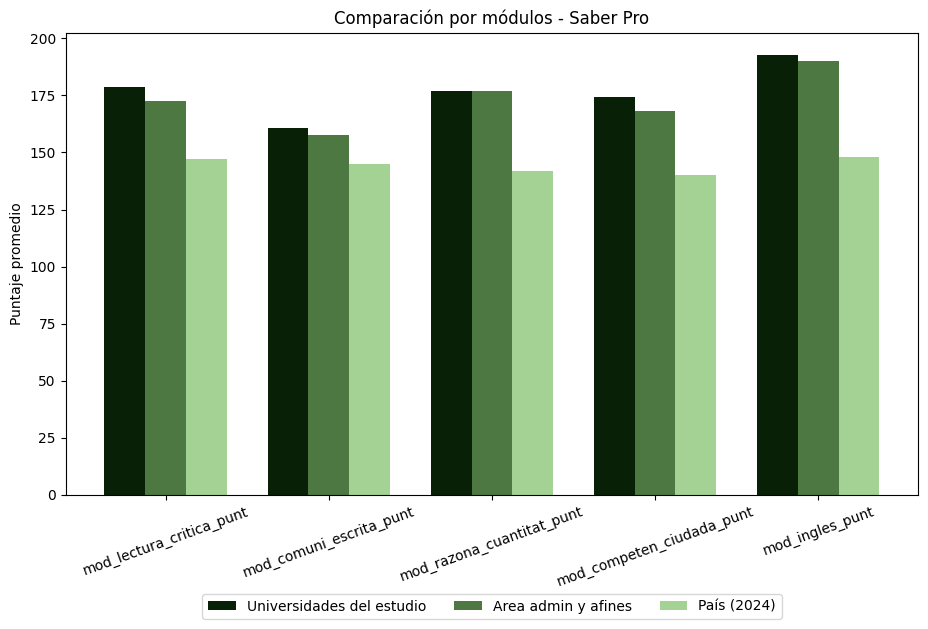

In [ ]:
# ===============================
# 5. GRÁFICA
# ===============================
x = range(len(df_plot))

plt.figure(figsize=(11,6))

plt.bar([i - 0.25 for i in x], df_plot["Total universidades"],
        width=0.25, label="Universidades del estudio", color="#082006")

plt.bar([i for i in x], df_plot["Gestión"],
        width=0.25, label="Area admin y afines", color="#4e7842")

plt.bar([i + 0.25 for i in x], df_plot["País (2024)"],
        width=0.25, label="País (2024)", color="#a4d295")

plt.xticks(x, df_plot["Modulo"], rotation=20)
plt.ylabel("Puntaje promedio")
plt.title("Comparación por módulos - Saber Pro")

plt.legend(    loc='upper center',
    bbox_to_anchor=(0.5, -0.20),
    ncol=3)
plt.show()